# GLM-HMM fit to data

Notebook to fit the GLM-HMM from Ashwood et al. (2020) ([Mice alternate between discrete strategies during perceptual decision-making](https://www.nature.com/articles/s41593-021-01007-z)).

Based on the example notebook [2b Input Driven Observations (GLM-HMM)](https://github.com/zashwood/ssm/blob/master/notebooks/2b%20Input%20Driven%20Observations%20(GLM-HMM).ipynb).

The logic of the original notebook is to simulate synthetic data with a generative GLM-HMM, fit a GLM-HMM to the synthetic data, and check that we can recover the generative parameters. Following that tutorial, we will use real data from my 2AFC task instead, fit a GLM-HMM to it and recover the parameters. Easy peasy, lemon squeezy!

## 1. Setup
The line `import ssm` imports the package for use. Here, we have also imported a few other packages for plotting.

In [51]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from glmhmm import *

In [52]:
# Plotting style
default_figsize = np.array(plt.rcParams['figure.figsize'])
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('poster')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

## 2. Input Driven Observations
We create a HMM with input-driven observations and 'standard' (stationary) transitions with the following line:
```python
        ssm.HMM(num_states, obs_dim, input_dim, observations="input_driven_obs", observation_kwargs=dict(C=num_categories), transitions="standard")
```

As in Ashwood et al. (2020), we are going to model an animal's binary choice data during a decision-making task, so we will set `num_categories=2` because the animal only has two options available to it. We will also set `obs_dim = 1` because the dimensionality of the observation data is 1 (if we were also modeling, for example, the binned reaction time of the animal, we could set `obs_dim = 2`).  For the sake of simplicity, we will assume that an animal's choice in a particular state is only affected by the external stimulus associated with that particular trial, and its innate choice bias. Thus, we will set `input_dim = 2` and we will simulate input data that resembles sequences of stimuli in what follows.  In Ashwood et al. (2020), they found that many mice used 3 decision-making states when performing 2AFC tasks. We will, thus, set `num_states = 3`.

Instead of generating data, we will use real data from my 2AFC task.

In [53]:
# Load data from example mouse
df = pd.read_csv(Path.home()/'PycharmProjects'/'glue_sessions'/'2AFC_2'/'333.csv')

# Filters for groups 1-3
df = df[df.Stage == 4].reset_index(drop=True)
df = df[df.Motor == 4].reset_index(drop=True)
# df = df[df.StimDur == 1].reset_index(drop=True)
df = df[df.P > 0].reset_index(drop=True)

# Drop misses (Choice == NaN)
df = df.dropna(subset=['Choice']).reset_index(drop=True)

In [54]:
# Add session index per trial for plotting accuracy
session_index = pd.factorize(df['Session'])[0]  # Get session index per trial
loc = df.columns.get_loc('Session') + 1  # To the right of Session column
df.insert(loc, 'SessionIndex', session_index)  # Add session index column

# Remove bad sessions with few trials (and therefore missing at least one of the stimulus evidences)
bad_sessions = []
# Count number of trials per session
for session_id, df_session in df.groupby('Session'):
    if len(df_session.ILD.abs().unique()) != len(df.ILD.abs().unique()):  # Should be 5 (including 0)
        print(f'Session {session_id} does not have enough trials, skipping...')
        bad_sessions.append(session_id)

# Remove bad sessions from df
df = df[~df.Session.isin(bad_sessions)].reset_index(drop=True)

Session 333_stage_training_v2_20220329-150606 does not have enough trials, skipping...
Session 333_stage_training_v2_20220704-104525 does not have enough trials, skipping...
Session 333_stage_training_v2_20220705-100059 does not have enough trials, skipping...


In [55]:
# Compute action trace over all sessions
# df['ActionTrace'] = (df.groupby('SessionIndex', group_keys=False).apply(lambda g: pd.Series(get_action_trace(g), index=g.index)))

To prepare the data for the GLM-HMM, we need to organize both the inputs (external covariates) and the choices (observations) **as lists of arrays, one per session**.

In this example, `df` contains the data from one or multiple sessions concatenated.

- **Inputs**: For each session, we create a 2D array of shape $(N_i, D)$, where $N_i$ is the number of trials in that session and $D=2$ is the number of input dimensions. Here, the two columns are:
  1. `df.ILD.values` — the stimulus presented on each trial
  2. A constant column of 1s — to capture the animal's baseline bias
- **Choices**: For each session, we create a 2D array of shape $(N_i, 1)$, where $N_i$ is the number of trials in that session. This array contains the animal's choices (0 or 1) for each trial.

In [56]:
# Parse the data
inputs, choices = parse_glmhmm(df, covariates=['net_ild', 'bias', 'at_error', 'at_correct'])

### Initialize GLM-HMM (2a)

In [57]:
# Set the parameters of the GLM-HMM
n_states = 2        # number of discrete states (from Ashwood et al. 2020)
obs_dim = 1         # number of observed dimensions (1 for binary choice)
n_categories = 2    # number of categories for output (2 for binary choice)
input_dim = inputs[0].shape[1]
# input_dim = 2       # input dimensions (stimulus, bias and action trace)
# input_dim = 11      # input dimensions (10 stimulus frames, bias and action trace)
# input_dim = 16      # input dimensions (10 stimulus frames residuals, net stimulus, bias and action trace)
# input_dim = 6       # input dimensions (net stimulus, bias and action trace)
# input_dim = 72       # input dimensions (net stimulus, bias and action trace)

In [58]:
glmhmm = ssm.HMM(n_states, obs_dim, input_dim, observations='input_driven_obs',
                   observation_kwargs=dict(C=n_categories), transitions='standard')

## 3. Fit GLM-HMM and perform recovery analysis

### 3a. Maximum Likelihood Estimation

Now we fit the GLM-HMM and check that we can recover the  parameters in the data:

In [59]:
# Fitting with stop earlier if increase in LL is below tolerance specified by tolerance parameter
method = 'em'       # Expectation Maximization method
num_iters = 200     # Max number of EM iterations
tolerance = 1e-4    # tolerance for stopping criterion
fit_ll = glmhmm.fit(choices, inputs=inputs, method='em', num_iters=num_iters, tolerance=tolerance)

  0%|          | 0/200 [00:00<?, ?it/s]

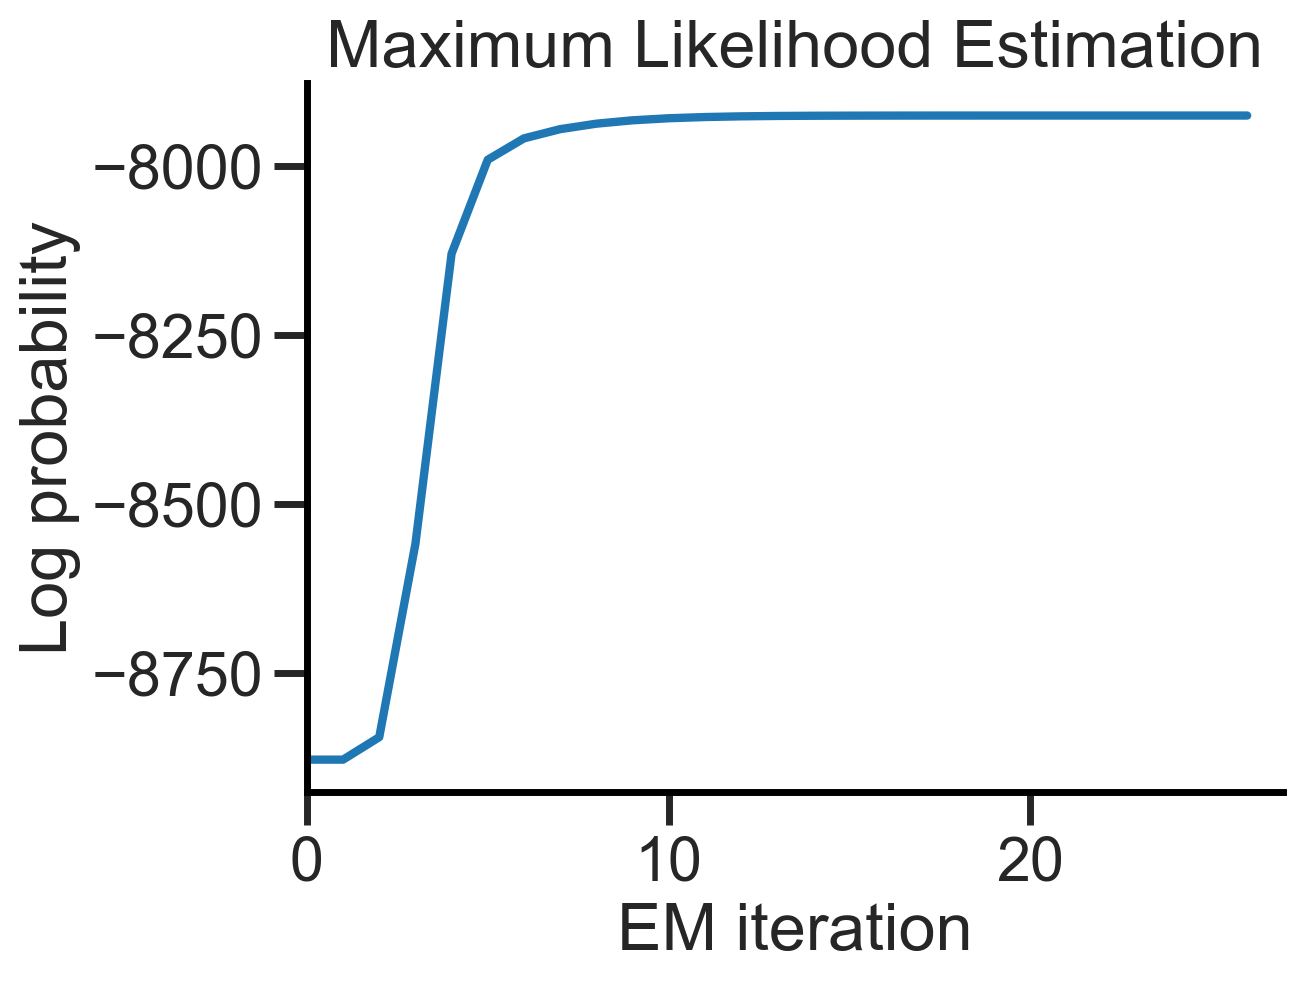

In [60]:
# Plot the log probabilities of the fit model
plt.figure(constrained_layout=True)
plt.plot(fit_ll)
plt.title('Maximum Likelihood Estimation')
plt.xlabel('EM iteration')
plt.xlim(0, len(fit_ll))
plt.ylabel('Log probability')
sns.despine()

### 3b. Retrieved parameters

In [61]:
weights = glmhmm.observations.params
weights = -weights  # Flip sign of weights
trans_mat = glmhmm.transitions.transition_matrix

Text(0.5, 1.0, 'Weights')

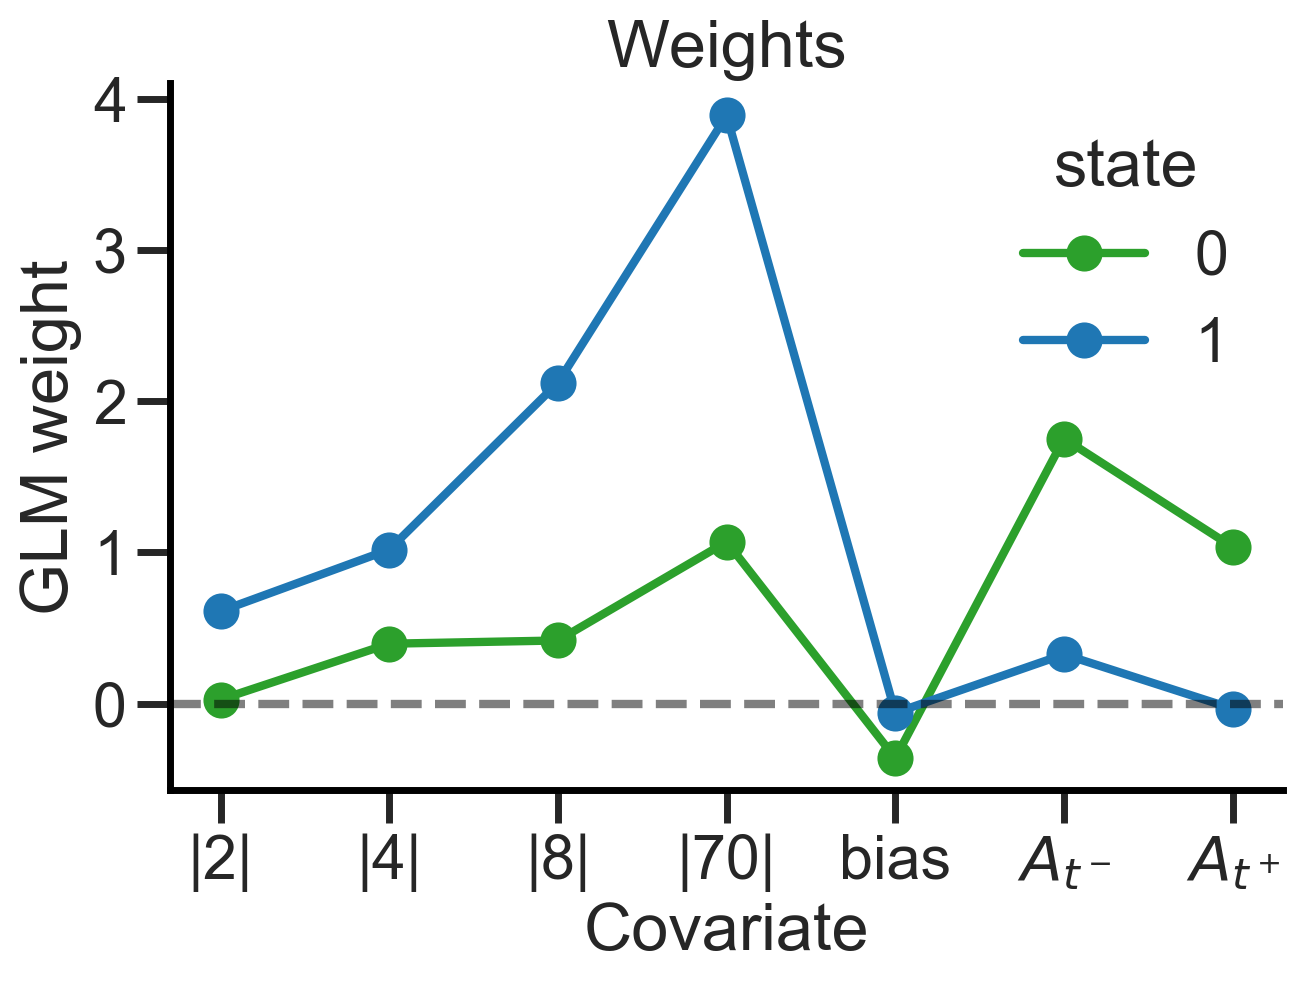

In [62]:
# Plot retrieved weights
# plt.figure(figsize=(default_figsize[1], default_figsize[1]), constrained_layout=True)
# plt.figure(figsize=(default_figsize[0]*2, default_figsize[1]), constrained_layout=True)
plt.figure(constrained_layout=True)
colors = ['tab:green', 'tab:blue', 'tab:orange']
for k in range(n_states):
    plt.plot(range(input_dim), weights[k][0], marker='o', color=colors[k], linestyle='-', label=str(k + 0))
plt.yticks()
plt.ylabel('GLM weight')
plt.xlabel('Covariate')
plt.xticks(np.arange(input_dim))
# plt.xticks(range(0, input_dim), ['stim.', 'bias'])
# plt.xticks(range(0, input_dim), ['stim.', 'bias', '$C_t$'])
# plt.xticks(np.arange(input_dim), [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'bias'])
# plt.xticks(np.arange(input_dim), [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, '|2|', '|4|', '|8|', '|70|', 'bias', 'Ct'], rotation=45)
# plt.xticks(np.arange(input_dim), ['|2|', '|4|', '|8|', '|70|', 'bias', 'Ct-', 'Ct+'])
plt.xticks(np.arange(input_dim), ['|2|', '|4|', '|8|', '|70|', 'bias', '$A_{t^-}$', '$A_{t^+}$'])
plt.legend(loc='best')
plt.axhline(y=0, color='k', alpha=0.5, ls='--')
plt.legend(title='state')
plt.title('Weights')

Text(0.5, 1.0, 'Transition matrix')

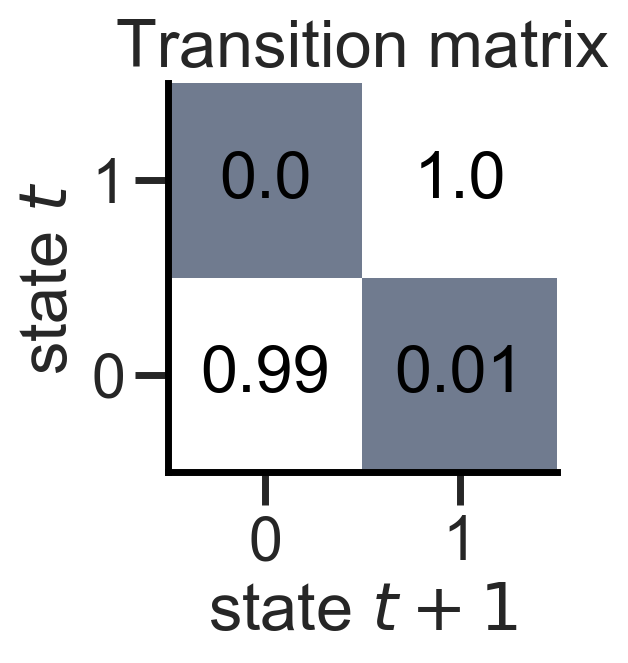

In [63]:
# Plot retrieved transition matrix
plt.figure(figsize=(default_figsize[0]/2, default_figsize[0]/2), constrained_layout=True)
# gen_trans_mat = np.exp(log_trans_mat)[0]
plt.imshow(trans_mat, vmin=-1, vmax=1, cmap='bone', origin='lower')

for i in range(trans_mat.shape[0]):
    for j in range(trans_mat.shape[1]):
        text = plt.text(j, i, str(np.around(trans_mat[i, j], decimals=2)), ha='center', va='center', color='k')

# plt.xlim(-0.5, n_states + 0.5)
ticks = range(0, n_states)
ticklabels = [str(i) for i in range(n_states)]
plt.xticks(ticks, ticklabels)
plt.yticks(ticks, ticklabels)
# plt.ylim(n_states - 0.5, -0.5)
plt.ylabel('state $t$')
plt.xlabel('state $t+1$')
plt.title('Transition matrix')

### 3c. Posterior State Probabilities

Let's now plot $p(z_{t} = k|\mathbf{y}, \{u_{t}\}_{t=1}^{T})$, the posterior state probabilities, which give the probability of the animal being in state k at trial t.

In [64]:
# Get expected states:
posterior_probs = [glmhmm.expected_states(data=data, input=input)[0]
                for data, input in zip(choices, inputs)]

AssertionError: 

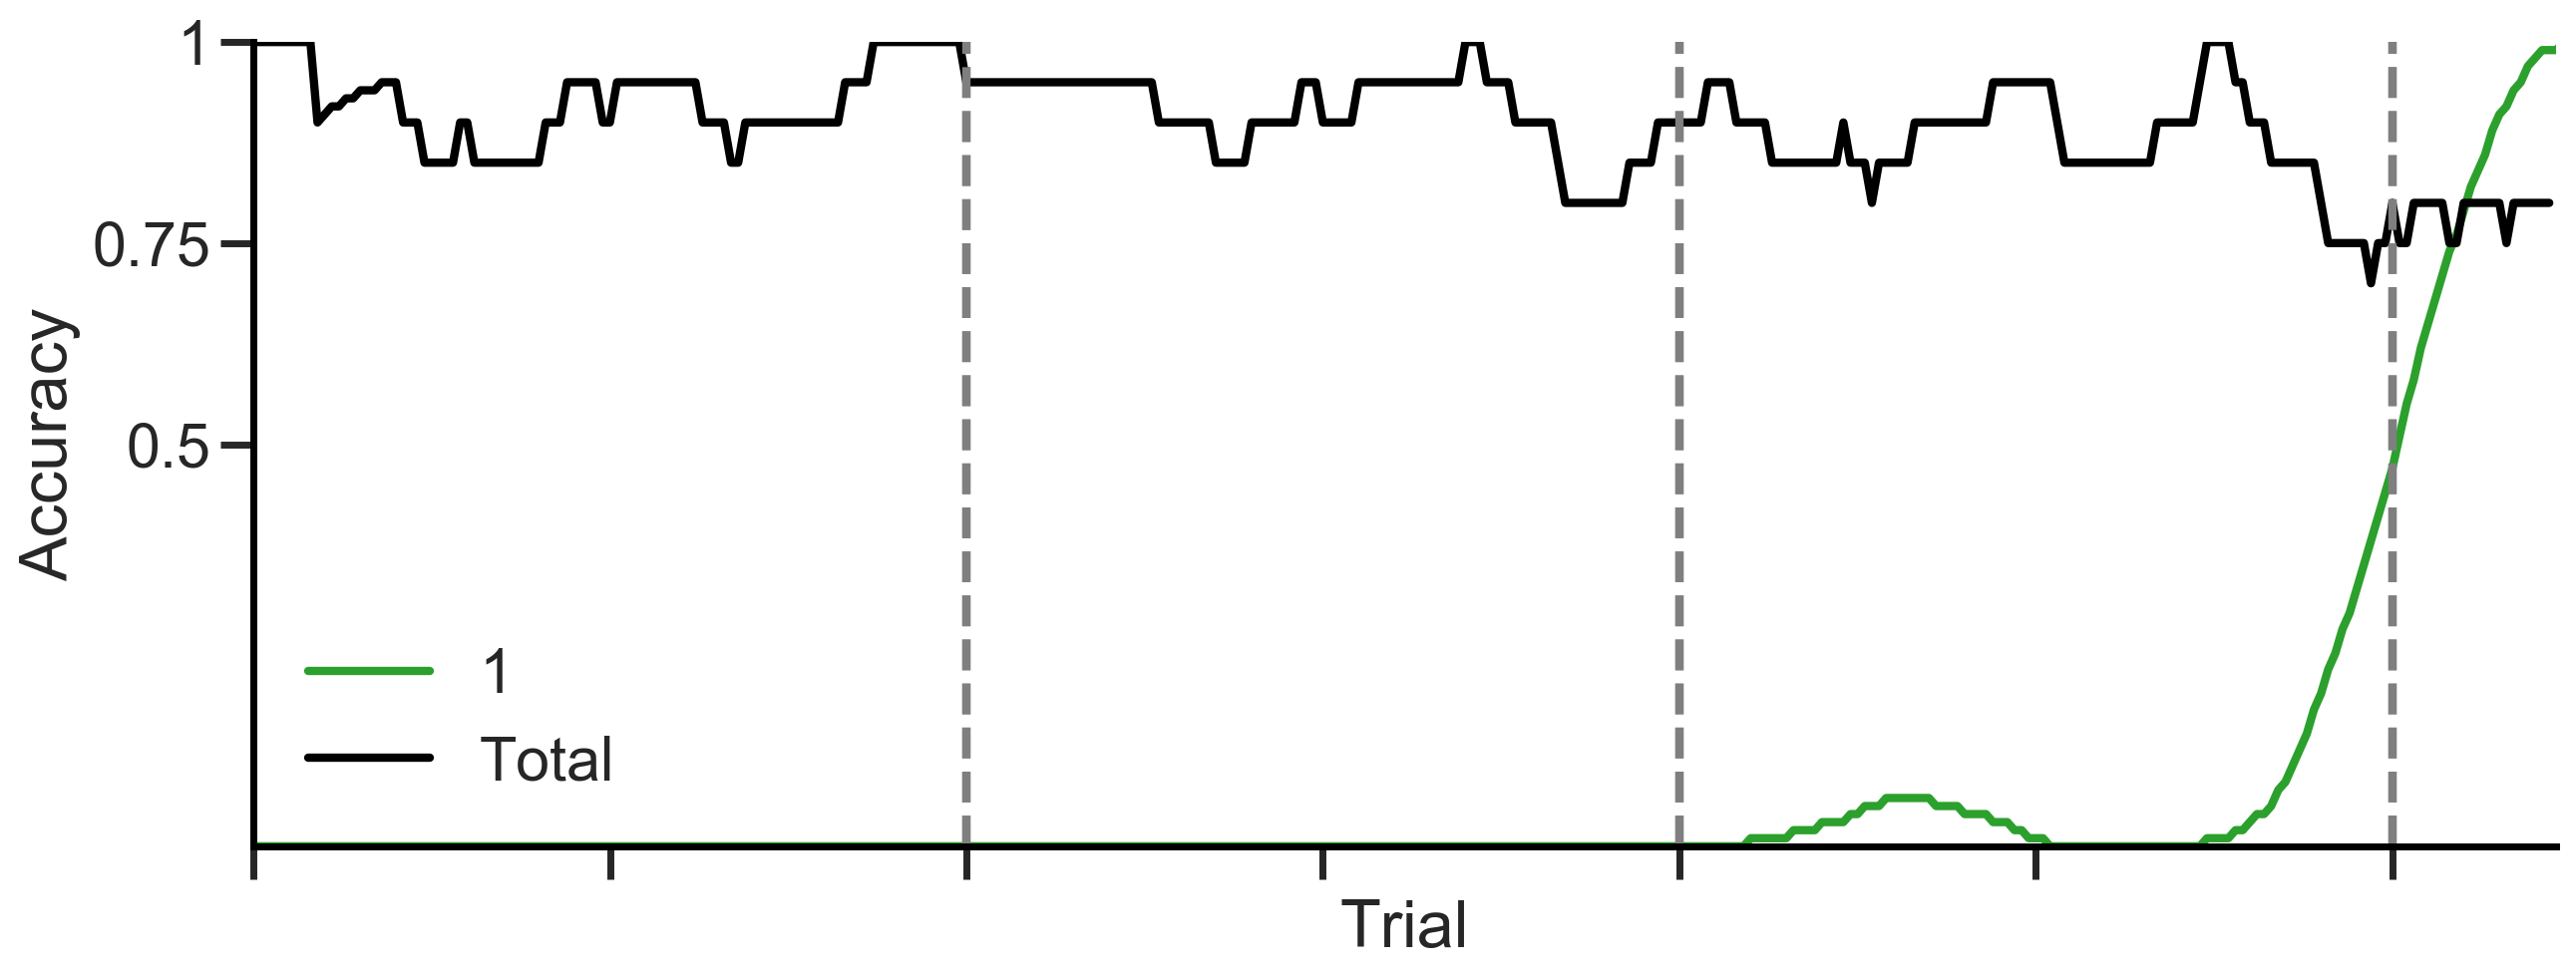

In [65]:
session_id = 50  # Can choose any index between 0 and n_sesssion

# Plot posterior state probabilities for one session
plt.figure(figsize=(default_figsize[0] * 2, default_figsize[1]), constrained_layout=True)

probs = posterior_probs[session_id]
plt.plot(compute_window(probs[:, 0]), color=colors[0], label=str(k + 0))
# for k in range(n_states):
#     # if k == 0:
#         # plt.plot(posterior_probs[session_id][:, k], color=colors[k], label=str(k + 1))
#         plt.plot(compute_window(probs[:, k]), color=colors[k], label=str(k + 0))

# plt.title('Posterior probabilities')
plt.xlim(0, len(probs))
plt.gca().set_xticklabels([])
plt.ylim(0, 1)
plt.yticks([0, 0.5, 1], ('0', '0.50', '1'))
# plt.xlabel('Trial')
plt.ylabel('p(state)')
plt.legend(title='state', loc='center right')

for x in range(100, len(probs), 100):
    plt.axvline(x, color='tab:gray', ls='--')


# Compute accuracy rolling averages
df_session = df[df.SessionIndex==session_id].reset_index(drop=True)
indices = df_session.index
hits = df_session.Hit.values
# Mask left and right accuracies by filling non-matching trials with NaN
hits_left = np.where(df_session.Side==0, hits, np.nan)
hits_right = np.where(df_session.Side==1, hits, np.nan)
ra_total = compute_window(hits)
ra_left = compute_window(hits_left)
ra_right = compute_window(hits_right)

# Plot accuracy for the same session
# plt.figure(figsize=(default_figsize[0]*2, default_figsize[1]), constrained_layout=True)
plt.plot(indices, ra_total, color='k', label='Total')
# plt.plot(indices, ra_left, color='tab:blue', label='Left')
# plt.plot(indices, ra_right, color='tab:orange', label='Right')
plt.xlim(0, len(ra_total))
plt.ylim((0, 1))
plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.yticks([0.5, 0.75, 1], ['0.5', '0.75', '1'])
# plt.title('Accuracy ')
plt.legend()

for x in range(100, len(df_session), 100):
    plt.axvline(x, color='tab:gray', ls='--')

assert len(probs) == len(ra_total)

With these posterior state probabilities, we can assign trials to states and then plot the fractional occupancy of each state:

In [ ]:
# Concatenate posterior probabilities across sessions
posterior_probs_concat = np.concatenate(posterior_probs)

# Get state with maximum posterior probability at particular trial
state_max_posterior = np.argmax(posterior_probs_concat, axis = 1)
df['State'] = state_max_posterior  # Add state column to df

# Obtain state fractional occupancies
_, state_occupancies = np.unique(state_max_posterior, return_counts=True)
state_occupancies = state_occupancies / np.sum(state_occupancies)

In [ ]:
fig = plt.figure(figsize=(default_figsize[1]/2, default_figsize[1]/2))

for z, occ in enumerate(state_occupancies):
    print(f'State {z+1} occupancy: {occ:.2f}')
    plt.bar(z, occ, color = colors[z])

plt.ylim((0, 1))
plt.xticks(ticks, ticklabels)
plt.yticks([0, 0.5, 1], ['0', '0.5', '1'])
plt.xlabel('State')
plt.ylabel('Fraction')
plt.title('Occupancy')
sns.despine()

# Interpret states and remap

In [ ]:
def interpret_states(weights):
    """
    Assigns labels to GLM-HMM states based on their weights.
    :param weights: GLM-HMM weights of shape (n_states, obs_dim, input_dim)
    :return: Dictionary mapping state index to label
    """

    stim_weights = weights[:, 0, 0]
    bias_weights = weights[:, 0, 1]

    # Engaged = max |stim|
    engaged = np.argmax(np.abs(stim_weights))

    # The other two states
    others = [s for s in range(len(weights)) if s != engaged]
    biased_left = others[np.argmin(bias_weights[others])]
    biased_right = others[np.argmax(bias_weights[others])]

    # Labels dictionary (original indexing)
    state_labels = {engaged: 'engaged',
                    biased_left: 'biased left',
                    biased_right: 'biased right'}

    # Remap so 0=engaged, 1=left, 2=right
    # remap = np.empty(len(weights), dtype=int)
    # remap[engaged] = 0
    # remap[biased_left] = 1
    # remap[biased_right] = 2

    remap = np.array([engaged, biased_left, biased_right])

    # Print state labels and weights
    for state, label in state_labels.items():
        print(f'State {state + 0}: {label} '
              f'(stim. weight: {stim_weights[state]:.2f}, '
              f'bias weight: {bias_weights[state]:.2f})')

    return state_labels, remap

In [ ]:
# Interpret states
state_labels, remap = interpret_states(weights)

In [ ]:
# Remap weights
weights = weights[remap]
weights = weights[:2]
print(weights)
remap = remap[:2]

In [ ]:
def apply_remap(posterior_probs, state_max_posterior, remap, state_labels):
    """
    Remap posterior probabilities and most likely states to consistent labeling.

    :param posterior_probs: N sessions list of np.ndarray of shape (n_trials, n_states)
    :param state_max_posterior: np.ndarray of shape (n_trials,), argmax state indices
    :param remap: np.ndarray of shape (n_states,), mapping old -> new
    :param state_labels: dict, mapping old state idx -> label
    :return: posterior_probs_remapped, state_max_posterior_remapped, ordered_labels
    """

    # Apply remap to posterior probabilities
    posterior_probs_remapped = [p[:, remap] for p in posterior_probs]

    # Apply remap to most likely state
    state_max_posterior_remapped = remap[state_max_posterior]

    # Reorder labels according to remap
    state_labels_remapped = [state_labels[old] for old in remap]

    return posterior_probs_remapped, state_max_posterior_remapped, state_labels_remapped

In [ ]:
# Apply remap
posterior_probs, state_max_posterior, state_labels = apply_remap(
    posterior_probs, state_max_posterior, remap, state_labels)

In [ ]:
from scipy.special import expit as logistic
from matplotlib.lines import Line2D

stim_range = np.linspace(-1, 1, 100)  # Theory
x = sorted(df.ILD.unique())  # Data
x = x / abs(max(x))

plt.figure(constrained_layout=True)
for state in range(weights.shape[0]):
    print(state)
    w_stim = weights[state, 0, 0]
    w_bias = weights[state, 0, 1]
    probs = logistic(w_stim * stim_range + w_bias)
    plt.plot(stim_range, probs, color=colors[state])  # Theory
    y = df[df.State==state].groupby('ILD').Choice.mean()
    plt.plot(x, y, marker='o', linestyle='None', color=colors[state])  # Data

# Create custom legend: line + dot together
legend_elements = [Line2D([0], [0], color=colors[state], marker='o', label=state_labels[state]) for state in range(weights.shape[0])]

plt.xlabel('Stimulus (norm. ILD)')
plt.ylabel('P(right)')
plt.title('Psychometric curves')
plt.legend(handles=legend_elements)

# Playground

The **action trace** $C_t$ is a measure of how past choices influence current behavior, with more recent choices having a greater impact. It is calculated as an exponentially weighted sum of past choices, where the weights decay over time according to a time constant $\tau$. The formula for the action trace at trial $t$ is given by:

$$
C_t=\sum_{i=1}^{k} e^{-k/\tau} \cdot r_{t-i}
$$

In [ ]:
# Plot action trace of the same session as before
plt.figure(figsize=(default_figsize[0] * 2, default_figsize[1]), constrained_layout=True)
action_trace = df[df.SessionIndex==session_id].ActionTrace.values
plt.plot(indices, compute_window(action_trace), color='k')
plt.xlim(0, len(action_trace))
plt.xlabel('Trial')
plt.ylabel('Action trace')
# plt.title(f'$k$={max_trial_lag}, $tau$={tau}')

for x in range(100, len(probs), 100):
    plt.axvline(x, color='tab:gray', ls='--')

In [ ]:
# Action trace psychometric curve

# 9 bins from -1 to 1
bin_centers = np.linspace(-1, 1, 9)
bin_edges = np.linspace(-1.1, 1.1, 10)

# Assign each value to a bin index
action_trace = df.ActionTrace
bin_idx = np.digitize(action_trace, bin_edges, right=False) - 1
bin_idx = np.clip(bin_idx, 0, 8)  # Ensure indices are within 0–8

df['BinCenter'] = bin_centers[bin_idx]
y = df.groupby('BinCenter')['Choice'].mean()

# Plot psychometric curve
plt.figure(constrained_layout=True)
plt.plot(y.index, y.values, marker='o', color='k')
plt.xticks(bin_centers, ('-1', '', '', '', '0', '', '', '', '1' ))
plt.xlabel('Action trace (norm.)')
plt.ylabel('P(right)')
plt.title('Psychometric curve')

In [ ]:
from scipy.special import expit as logistic
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

# 9 bins for action traces
bin_centers = np.linspace(-1, 1, 9)
bin_edges = np.linspace(-1.1, 1.1, 10)

plt.figure(constrained_layout=True)

for state in range(weights.shape[0]):
    # logistic fit over continuous stim range (theory)
    w_action = weights[state, 0, 2]
    w_bias = weights[state, 0, 1]
    stim_range = np.linspace(-1, 1, 100)
    probs = logistic(w_action * stim_range + w_bias)
    plt.plot(stim_range, probs, color=colors[state])  # theory

    # Data: binned action traces
    df_state = df[df.State == state].copy()
    bin_idx = np.digitize(df_state['ActionTrace'], bin_edges, right=False) - 1
    bin_idx = np.clip(bin_idx, 0, 8)
    df_state['BinCenter'] = bin_centers[bin_idx]

    y = df_state.groupby('BinCenter')['Choice'].mean()
    plt.plot(y.index, y.values, marker='o', linestyle='None', color=colors[state])  # data

# Legend: line + dot
legend_elements = [Line2D([0], [0], color=colors[state], marker='o', label=state_labels[state])
                   for state in range(weights.shape[0])]

plt.xlabel('Action trace (norm.)')
plt.ylabel('P(right)')
plt.title('Psychometric curves by action trace')
plt.xticks(bin_centers, ['-1', '', '', '', '0', '', '', '', '1'])
plt.legend(handles=legend_elements)
plt.show()